In [304]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!gdown --fuzzy "https://docs.google.com/spreadsheets/d/1yFM-pBU6wfMdDNpK-aJOyuYt6QfuYPLm/edit?usp=drive_link&ouid=103033907322537253466&rtpof=true&sd=true"
!gdown --fuzzy "https://drive.google.com/file/d/1hXDi2qpz1zCC8FGaDeLsbn-Mlq3jF3a-/view?usp=drive_link"
!gdown --fuzzy "https://drive.google.com/file/d/1SLaoxTu8MtnSjV_zCn1i5gl8JRKoEJrL/view?usp=drive_link"
!gdown --fuzzy "https://drive.google.com/file/d/1PAdLrEs3pSksXbcXLkxJ9BZYvy1CbcZC/view?usp=drive_link"
!gdown --fuzzy "https://docs.google.com/spreadsheets/d/1IcsTuvWuo4Jhz-zot2dq8KdZGUEJP1s7/edit?usp=drive_link&ouid=103033907322537253466&rtpof=true&sd=true"

Downloading...
From: https://drive.google.com/uc?id=1yFM-pBU6wfMdDNpK-aJOyuYt6QfuYPLm
To: /content/CustomersData.xlsx
100% 42.2k/42.2k [00:00<00:00, 71.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hXDi2qpz1zCC8FGaDeLsbn-Mlq3jF3a-
To: /content/Discount_Coupon.csv
100% 4.92k/4.92k [00:00<00:00, 10.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1SLaoxTu8MtnSjV_zCn1i5gl8JRKoEJrL
To: /content/Marketing_Spend.csv
100% 8.67k/8.67k [00:00<00:00, 19.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PAdLrEs3pSksXbcXLkxJ9BZYvy1CbcZC
To: /content/Online_Sales.csv
100% 5.24M/5.24M [00:00<00:00, 28.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IcsTuvWuo4Jhz-zot2dq8KdZGUEJP1s7
To: /content/Tax_amount.xlsx
100% 9.84k/9.84k [00:00<00:00, 20.6MB/s]


In [305]:
CustomersData = pd.read_excel("CustomersData.xlsx")
Discount_Coupon = pd.read_csv("Discount_Coupon.csv")
Marketing_Spend = pd.read_csv("Marketing_Spend.csv")
Online_Sales = pd.read_csv("Online_Sales.csv")
Tax_amount = pd.read_excel("Tax_amount.xlsx")

Need Fix DiscountCoupon,Marketing_Spend,Online_Sales ( Date Column changed to Datetime Datatype)

In [306]:
Marketing_Spend['Date'] = pd.to_datetime(Marketing_Spend['Date'])
Online_Sales['Transaction_Date'] = pd.to_datetime(Online_Sales['Transaction_Date'])
Discount_Coupon['Month'] = pd.to_datetime(Discount_Coupon['Month'] + '-2019', format='%b-%Y').dt.to_period('M')
# Discount_Coupon["Month"]

In [307]:
dataSets = {"CustomersData":CustomersData,"Discount_Coupon":Discount_Coupon,"Marketing_Spend":Marketing_Spend,"Online_Sales":Online_Sales,"Tax_amount":Tax_amount}

In [308]:
for name,df in dataSets.items():
  print(f"-->  Name:----  {name}   -   shape - {df.shape} -- Columns -- {df.columns.tolist()} ")
  print(f"--> {df.head()}")
  print(f"-->  object values type  -  -  {df.dtypes}")
  print(f"--> is NUll {df.isnull().sum()}")
  print(f"--> is Duplicate   {df.duplicated().sum()}")
  print('---------------------------------------------------------------------')

-->  Name:----  CustomersData   -   shape - (1468, 4) -- Columns -- ['CustomerID', 'Gender', 'Location', 'Tenure_Months'] 
-->    CustomerID Gender    Location  Tenure_Months
0       17850      M     Chicago             12
1       13047      M  California             43
2       12583      M     Chicago             33
3       13748      F  California             30
4       15100      M  California             49
-->  object values type  -  -  CustomerID        int64
Gender           object
Location         object
Tenure_Months     int64
dtype: object
--> is NUll CustomerID       0
Gender           0
Location         0
Tenure_Months    0
dtype: int64
--> is Duplicate   0
---------------------------------------------------------------------
-->  Name:----  Discount_Coupon   -   shape - (204, 4) -- Columns -- ['Month', 'Product_Category', 'Coupon_Code', 'Discount_pct'] 
-->      Month Product_Category Coupon_Code  Discount_pct
0  2019-01          Apparel      SALE10            10
1  2019-0

Merging Data
The Online_Sales dataset was enriched by merging customer demographics, discount coupon details, GST rates, and daily marketing spend. LEFT JOINs were used throughout to ensure that no transaction records were lost. Discount coupons were mapped based on transaction month and product category, GST was added using product category, and marketing spend was merged using transaction date.”

In [309]:
merged_df = pd.merge(Online_Sales,CustomersData,on='CustomerID',how='left')

In [310]:
merged_df['Month'] = merged_df['Transaction_Date'].dt.to_period('M')

In [311]:
# merged_df.head()
merged_df = pd.merge(merged_df,Discount_Coupon,left_on=['Month','Product_Category'],right_on=['Month','Product_Category'],how='left')

In [312]:
merged_df = pd.merge(merged_df,Tax_amount,on='Product_Category',how='left')

In [313]:
merged_df = pd.merge(merged_df,Marketing_Spend,left_on='Transaction_Date',right_on='Date',how='left')

In [314]:
merged_df['Discount_Decimal'] = merged_df['Discount_pct'].fillna(0)/100
merged_df['GST_Decimal'] = merged_df['GST'].fillna(0)/100

Invoice value was calculated by applying discounts and GST on product price and adding delivery charges.


In [315]:
merged_df['Invoice_Value'] = (merged_df['Quantity']*merged_df['Avg_Price']*(1-merged_df['Discount_Decimal'])*(1+merged_df['GST_Decimal'])+merged_df['Delivery_Charges'])

In [316]:
# Q1.
grp_df1 = merged_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
grp_df1['AcquisitionMonth'] = grp_df1['Transaction_Date'].dt.to_period('M')
grp_df1_monthly = grp_df1.groupby('AcquisitionMonth').size().reset_index(name='TotalCustomer')
grp_df1_monthly

,AcquisitionMonth,TotalCustomer
0,2019-01,215
1,2019-02,96
2,2019-03,177
3,2019-04,163
4,2019-05,112
5,2019-06,137
6,2019-07,94
7,2019-08,135
8,2019-09,78
9,2019-10,87


**Q1 Result: Customer acquisition was calculated by identifying the earliest transaction date for each customer and grouping customers by their acquisition month**

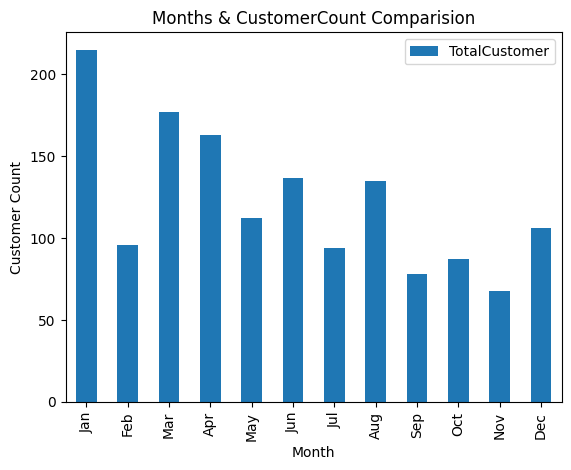

In [317]:
# Q2.
grp_df1_monthly.plot(kind='bar', title='Months & CustomerCount Comparision')
plt.xlabel('Month')
plt.ylabel('Customer Count')
month_starts = [0,1,2,3,4,5,6,7,8,9,10,11]
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
plt.gca().set_xticks(month_starts)
plt.gca().set_xticklabels(month_names)
plt.show()

**Q2 Result : Customer sign-ups were highest in January 2019, with 215 customers, followed by March and April. The lowest number of customers came in November, with just 68 sign-ups .
Customer sign-ups are higher at the start of the year and lower toward the end. Strong months can be used for aggressive marketing, while discounts and remarketing can boost growth during slower months**

In [318]:
# Q3
monthly_customer = merged_df.groupby('Month')['CustomerID'].apply(set).reset_index(name='Customer')
retainedRateList = []
for i in range(len(monthly_customer)-1):
  mx = monthly_customer.loc[i,'Month']
  my = monthly_customer.loc[i+1,'Month']
  cx = monthly_customer.loc[i,'Customer']
  cy = monthly_customer.loc[i+1,'Customer']
  repeat_customer = len(cx.intersection(cy))
  retainedRate = repeat_customer/len(cx)
  retainedRateList.append({"Month":mx,"Next Month":my,"RetentionRate":round(retainedRate*100,2)})

retainedRateFrame = pd.DataFrame(retainedRateList)

**Q3 Result :
Monthly retention analysis shows that Month May-June-July & July-August stronger customer retention, and weaker in remaining all.
Retention rate for January and December is not calculated due to unavailability of previous and next month data respectively**

In [319]:
# Q4
highRetentionMonth = retainedRateFrame[retainedRateFrame['RetentionRate'] > retainedRateFrame['RetentionRate'].mean()]['Month']
lowRetentionMonth = retainedRateFrame[retainedRateFrame['RetentionRate'] <= retainedRateFrame['RetentionRate'].mean()]['Month']
# highRetentionMonth
# lowRetentionMonth

In [320]:
RetentionMonthData = merged_df[merged_df['Month'].isin(highRetentionMonth)]
RetentionMonthData.groupby('Product_Category')['Quantity'].sum().sort_values(ascending=False)

,Quantity
Product_Category,
Office,22728
Apparel,9687
Drinkware,8164
Lifestyle,7171
Nest-USA,4882
Bags,3858
Notebooks & Journals,3194
Housewares,1222
Bottles,775


In [321]:
RetentionMonthData['Discount_pct'].describe()

,Discount_pct
count,13871.000000
mean,19.252397
std,8.178556
min,10.000000
25%,10.000000
50%,20.000000
75%,30.000000
max,30.000000


In [322]:
RetentionMonthData['Invoice_Value'].describe()

,Invoice_Value
count,14016.000000
mean,66.824808
std,111.477577
min,6.553553
25%,15.584221
50%,26.697985
75%,93.988580
max,4055.323650


In [323]:
averageOrder = merged_df.groupby('Month')['Invoice_Value'].mean()
averageOrder

,Invoice_Value
Month,
2019-01,104.152752
2019-02,90.946078
2019-03,70.640369
2019-04,97.316043
2019-05,63.138695
2019-06,62.756984
2019-07,73.282491
2019-08,62.240347
2019-09,68.537730


**Q4 Result: Most sell Product category, Discount, Average Order value shown in Code.**

In [324]:
# Q5
first_purchase = merged_df.groupby('CustomerID')['Month'].min().reset_index(name='FirstMonth')
merged_df = merged_df.merge(first_purchase[['CustomerID','FirstMonth']],on='CustomerID',how='left')
merged_df['CustomerType'] = np.where(merged_df['Month']==merged_df['FirstMonth'],'New','Existing')
monthlyRevenue = merged_df.groupby(['Month','CustomerType'])['Invoice_Value'].sum().reset_index(name='Revenue')
monthlyRevenue

,Month,CustomerType,Revenue
0,2019-01,New,423172.633400
1,2019-02,Existing,37478.011237
2,2019-02,New,261188.907665
3,2019-03,Existing,52517.555655
4,2019-03,New,254485.487273
5,2019-04,Existing,164724.447770
6,2019-04,New,239137.129753
7,2019-05,Existing,104291.912479
8,2019-05,New,184378.202187
9,2019-06,Existing,106240.287937


**Q5 Result : The analysis shows that revenue in the early months is mainly driven by new customers, indicating strong acquisition efforts.
From mid to late months, existing customers contribute more revenue, showing improved retention and repeat purchases.**

In [325]:
#6
CouponTransaction = merged_df.groupby('Coupon_Status')['Invoice_Value'].sum().reset_index(name="Total_Amount")
CouponTransaction

,Coupon_Status,Total_Amount
0,Clicked,2.196822e+06
1,Not Used,6.698822e+05
2,Used,1.438898e+06


In [326]:
avg_value = merged_df.groupby('Coupon_Status')['Invoice_Value'].mean().reset_index(name="Average_Value")
avg_value

,Coupon_Status,Average_Value
0,Clicked,81.587375
1,Not Used,82.762811
2,Used,80.367404


**Q6 Result : Coupons help in increasing number of transactions, but slightly reduce per-order value.**

In [327]:
#7
# merged_df.head()
prByQty = merged_df.groupby(['Product_SKU','Product_Description','Product_Category']).agg(Total_qty = ('Quantity','sum'),Total_rev = ('Invoice_Value','sum')).reset_index()
prByQty.sort_values(['Total_qty','Total_rev'],ascending=False).head(20)

,Product_SKU,Product_Description,Product_Category,Total_qty,Total_rev
914,GGOEGGOA017399,Maze Pen,Office,16234,17069.872812
880,GGOEGDHC018299,Google 22 oz Water Bottle,Drinkware,9728,29422.984048
854,GGOEGBMJ013399,Sport Bag,Bags,7321,31787.203748
969,GGOEGOLC014299,Google Metallic Notebook Set,Office,6496,33541.437316
904,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,5847,21589.582818
907,GGOEGFSR022099,Google Kick Ball,Lifestyle,5549,12431.722959
983,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,5206,529054.847528
908,GGOEGFYQ016599,Foam Can and Bottle Cooler,Drinkware,5098,9351.747780
942,GGOEGOAQ012899,Ballpoint LED Light Pen,Office,4861,13156.329940
981,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,4570,578977.668511


**Q7 Result:
Top performing product by qty are pens notebook drinkware.
Top performing product by revenue are Nest-Usa Product.**

In [328]:
#8
monthly_revenue = merged_df.groupby('Month')['Invoice_Value'].sum().reset_index()
monthly_revenue

,Month,Invoice_Value
0,2019-01,423172.633400
1,2019-02,298666.918902
2,2019-03,307003.042928
3,2019-04,403861.577522
4,2019-05,288670.114666
5,2019-06,263140.033943
6,2019-07,384806.358026
7,2019-08,382778.132330
8,2019-09,293889.785084
9,2019-10,415195.195895


In [329]:
marketing_monthly = (merged_df[['Date', 'Offline_Spend', 'Online_Spend']].drop_duplicates(subset=['Date']))
marketing_monthly['TotalMarketingSpend'] = (marketing_monthly['Offline_Spend'] +marketing_monthly['Online_Spend'])
marketing_monthly

,Date,Offline_Spend,Online_Spend,TotalMarketingSpend
0,2019-01-01,4500,2424.50,6924.50
89,2019-01-02,4500,3480.36,7980.36
204,2019-01-03,4500,1576.38,6076.38
411,2019-01-04,4500,2928.55,7428.55
580,2019-01-05,4500,4055.30,8555.30
...,...,...,...,...
52524,2019-12-27,4000,3396.87,7396.87
52627,2019-12-28,4000,3246.84,7246.84
52707,2019-12-29,4000,2546.58,6546.58
52796,2019-12-30,4000,674.31,4674.31


In [330]:
marketing_monthly['Month'] = marketing_monthly['Date'].dt.to_period('M')
monthlyMarketing = marketing_monthly.groupby('Month')['TotalMarketingSpend'].sum().reset_index()
monthlyMarketing


,Month,TotalMarketingSpend
0,2019-01,154928.95
1,2019-02,137107.92
2,2019-03,122250.09
3,2019-04,157026.83
4,2019-05,118259.64
5,2019-06,134318.14
6,2019-07,120217.85
7,2019-08,142904.15
8,2019-09,135514.54
9,2019-10,151224.65


In [331]:
monthlyMarketing_check = pd.merge(monthly_revenue,monthlyMarketing,on='Month',how='left')
monthlyMarketing_check

,Month,Invoice_Value,TotalMarketingSpend
0,2019-01,423172.633400,154928.95
1,2019-02,298666.918902,137107.92
2,2019-03,307003.042928,122250.09
3,2019-04,403861.577522,157026.83
4,2019-05,288670.114666,118259.64
5,2019-06,263140.033943,134318.14
6,2019-07,384806.358026,120217.85
7,2019-08,382778.132330,142904.15
8,2019-09,293889.785084,135514.54
9,2019-10,415195.195895,151224.65


In [332]:
monthlyMarketing_check['ROI'] = ((monthlyMarketing_check['Invoice_Value']-monthlyMarketing_check['TotalMarketingSpend'])*100)/monthlyMarketing_check['TotalMarketingSpend']
monthlyMarketing_check

,Month,Invoice_Value,TotalMarketingSpend,ROI
0,2019-01,423172.633400,154928.95,173.139806
1,2019-02,298666.918902,137107.92,117.833455
2,2019-03,307003.042928,122250.09,151.127049
3,2019-04,403861.577522,157026.83,157.192721
4,2019-05,288670.114666,118259.64,144.098591
5,2019-06,263140.033943,134318.14,95.908039
6,2019-07,384806.358026,120217.85,220.090867
7,2019-08,382778.132330,142904.15,167.856554
8,2019-09,293889.785084,135514.54,116.869559
9,2019-10,415195.195895,151224.65,174.555237


In [333]:
highROI = monthlyMarketing_check.loc[monthlyMarketing_check['ROI']>monthlyMarketing_check['ROI'].mean()]
highROI.sort_values('ROI',ascending=False)

,Month,Invoice_Value,TotalMarketingSpend,ROI
6,2019-07,384806.358026,120217.85,220.090867
9,2019-10,415195.195895,151224.65,174.555237
0,2019-01,423172.633400,154928.95,173.139806
10,2019-11,439901.659354,161144.96,172.985056
7,2019-08,382778.132330,142904.15,167.856554
3,2019-04,403861.577522,157026.83,157.192721
2,2019-03,307003.042928,122250.09,151.127049


In [334]:
lowROI = monthlyMarketing_check.loc[monthlyMarketing_check['ROI']<monthlyMarketing_check['ROI'].mean()]
lowROI.sort_values('ROI',ascending=True)['Month']

,Month
5,2019-06
11,2019-12
8,2019-09
1,2019-02
4,2019-05


**Q8 Result :
High ROI Month July(220%) august(174%) January(173%) and Low ROI Month is June(95%) December(103%) September(116%).**

In [335]:
#9
monthlyMarketing_check['MarketingSpend'] = (monthlyMarketing_check['TotalMarketingSpend']*100)/monthlyMarketing_check['Invoice_Value']
monthlyMarketing_check

,Month,Invoice_Value,TotalMarketingSpend,ROI,MarketingSpend
0,2019-01,423172.633400,154928.95,173.139806,36.611288
1,2019-02,298666.918902,137107.92,117.833455,45.906631
2,2019-03,307003.042928,122250.09,151.127049,39.820482
3,2019-04,403861.577522,157026.83,157.192721,38.881349
4,2019-05,288670.114666,118259.64,144.098591,40.967053
5,2019-06,263140.033943,134318.14,95.908039,51.044358
6,2019-07,384806.358026,120217.85,220.090867,31.241129
7,2019-08,382778.132330,142904.15,167.856554,37.333415
8,2019-09,293889.785084,135514.54,116.869559,46.110667
9,2019-10,415195.195895,151224.65,174.555237,36.422543


**Q9 Result :
According to Marketing spend % , Best Performing Month is July October and worst is June Feb .**

In [336]:
#10
today = merged_df['Transaction_Date'].max() + pd.Timedelta(days=1)
today

Timestamp('2020-01-01 00:00:00')

In [337]:
rfm = merged_df.groupby('CustomerID').agg({'Transaction_Date' : lambda x:(today-x.max()).days,'Transaction_ID':'count','Invoice_Value':'sum'}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346,108,2,171.725887
1,12347,60,60,10632.890268
2,12348,74,23,1341.274742
3,12350,18,17,1080.966849
4,12356,108,36,1648.281319
...,...,...,...,...
1463,18259,271,7,770.459148
1464,18260,88,40,2434.410793
1465,18269,195,8,140.122949
1466,18277,70,1,274.468200


In [338]:
r_bins = [0, 100, 200, 300, np.inf]
f_bins = [0, 40, 70, 100, np.inf]
m_bins = [0, 4000, 7000, 10000, np.inf]

rfm['R_Score'] = pd.cut(rfm['Recency'], bins=r_bins, labels=False) + 1
rfm['F_Score'] = pd.cut(rfm['Frequency'], bins=f_bins, labels=False) + 1
rfm['M_Score'] = pd.cut(rfm['Monetary'], bins=m_bins, labels=False) + 1


In [339]:
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,108,2,171.725887,2,1,1,4
1,12347,60,60,10632.890268,1,2,4,7
2,12348,74,23,1341.274742,1,1,1,3
3,12350,18,17,1080.966849,1,1,1,3
4,12356,108,36,1648.281319,2,1,1,4
...,...,...,...,...,...,...,...,...
1463,18259,271,7,770.459148,3,1,1,5
1464,18260,88,40,2434.410793,1,1,1,3
1465,18269,195,8,140.122949,2,1,1,4
1466,18277,70,1,274.468200,1,1,1,3


In [340]:
def classify_customer(score):
    if score <= 6:
        return 'Standard'
    elif score <= 9:
        return 'Silver'
    elif score <= 11:
        return 'Gold'
    else:
        return 'Premium'


In [341]:
rfm['Customer_Segment'] = rfm['RFM_Score'].apply(classify_customer)
print(rfm.head())

   CustomerID  Recency  Frequency      Monetary  R_Score  F_Score  M_Score  \
0       12346      108          2    171.725887        2        1        1   
1       12347       60         60  10632.890268        1        2        4   
2       12348       74         23   1341.274742        1        1        1   
3       12350       18         17   1080.966849        1        1        1   
4       12356      108         36   1648.281319        2        1        1   

   RFM_Score Customer_Segment  
0          4         Standard  
1          7           Silver  
2          3         Standard  
3          3         Standard  
4          4         Standard  


In [342]:
#11
segmentRevenue = merged_df.merge(rfm[['CustomerID','Customer_Segment']],on='CustomerID',how='left')
segmentRevenue.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,GST,Date,Offline_Spend,Online_Spend,Discount_Decimal,GST_Decimal,Invoice_Value,FirstMonth,CustomerType,Customer_Segment
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,0.10,2019-01-01,4500,2424.5,0.1,0.0010,144.977339,2019-01,New,Premium
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,0.10,2019-01-01,4500,2424.5,0.1,0.0010,144.977339,2019-01,New,Premium
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,0.10,2019-01-01,4500,2424.5,0.1,0.0010,8.346845,2019-01,New,Premium
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,0.18,2019-01-01,4500,2424.5,0.1,0.0018,85.526993,2019-01,New,Premium
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,0.18,2019-01-01,4500,2424.5,0.1,0.0018,21.376730,2019-01,New,Premium


In [343]:
segmentAnalysis = segmentRevenue.groupby('Customer_Segment').agg(TotalRevenue=('Invoice_Value','sum'),CustomerCount=('CustomerID','nunique'),TotalOrder=('Transaction_ID','count')).reset_index()
segmentAnalysis

,Customer_Segment,TotalRevenue,CustomerCount,TotalOrder
0,Gold,3.035425e+05,20,3364
1,Premium,4.722955e+04,2,403
2,Silver,1.731428e+06,180,20348
3,Standard,2.223402e+06,1266,28809


In [344]:
total_revenue = segmentAnalysis['TotalRevenue'].sum()
segmentAnalysis['RevenueContribution'] = (segmentAnalysis['TotalRevenue']/total_revenue)*100
segmentAnalysis

,Customer_Segment,TotalRevenue,CustomerCount,TotalOrder,RevenueContribution
0,Gold,3.035425e+05,20,3364,7.049944
1,Premium,4.722955e+04,2,403,1.096933
2,Silver,1.731428e+06,180,20348,40.213380
3,Standard,2.223402e+06,1266,28809,51.639743


In [345]:
#12
FirstPurchaseMonth = merged_df.groupby('CustomerID')['Month'].min().reset_index(name='CohortMonth')
cohort_df = merged_df.merge(FirstPurchaseMonth,on='CustomerID',how='left')
cohort_df

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,GST,Date,Offline_Spend,Online_Spend,Discount_Decimal,GST_Decimal,Invoice_Value,FirstMonth,CustomerType,CohortMonth
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,0.10,2019-01-01,4500,2424.50,0.1,0.0010,144.977339,2019-01,New,2019-01
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,0.10,2019-01-01,4500,2424.50,0.1,0.0010,144.977339,2019-01,New,2019-01
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,0.10,2019-01-01,4500,2424.50,0.1,0.0010,8.346845,2019-01,New,2019-01
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,0.18,2019-01-01,4500,2424.50,0.1,0.0018,85.526993,2019-01,New,2019-01
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,0.18,2019-01-01,4500,2424.50,0.1,0.0018,21.376730,2019-01,New,2019-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,0.10,2019-12-31,4000,2058.75,0.3,0.0010,91.494910,2019-12,New,2019-12
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,0.18,2019-12-31,4000,2058.75,0.3,0.0018,40.805639,2019-12,New,2019-12
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,0.10,2019-12-31,4000,2058.75,0.3,0.0010,112.922316,2019-12,New,2019-12
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,0.10,2019-12-31,4000,2058.75,0.3,0.0010,288.601820,2019-12,New,2019-12


In [346]:
cohort_df['CohortIndex'] = (cohort_df['Month'] - cohort_df['CohortMonth']).apply(lambda x:x.n)
cohort_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Date,Offline_Spend,Online_Spend,Discount_Decimal,GST_Decimal,Invoice_Value,FirstMonth,CustomerType,CohortMonth,CohortIndex
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,2019-01-01,4500,2424.5,0.1,0.0010,144.977339,2019-01,New,2019-01,0
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,2019-01-01,4500,2424.5,0.1,0.0010,144.977339,2019-01,New,2019-01,0
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,2019-01-01,4500,2424.5,0.1,0.0010,8.346845,2019-01,New,2019-01,0
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,2019-01-01,4500,2424.5,0.1,0.0018,85.526993,2019-01,New,2019-01,0
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,2019-01-01,4500,2424.5,0.1,0.0018,21.376730,2019-01,New,2019-01,0


In [347]:
cohort_table = cohort_df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_table

,CohortMonth,CohortIndex,CustomerID
0,2019-01,0,215
1,2019-01,1,13
2,2019-01,2,24
3,2019-01,3,34
4,2019-01,4,23
...,...,...,...
73,2019-10,1,6
74,2019-10,2,4
75,2019-11,0,68
76,2019-11,1,7


In [348]:
cohort_pv = cohort_table.pivot(index='CohortMonth',columns='CohortIndex',values='CustomerID')
retention_rate = cohort_pv.div(cohort_pv[0], axis=0) * 100

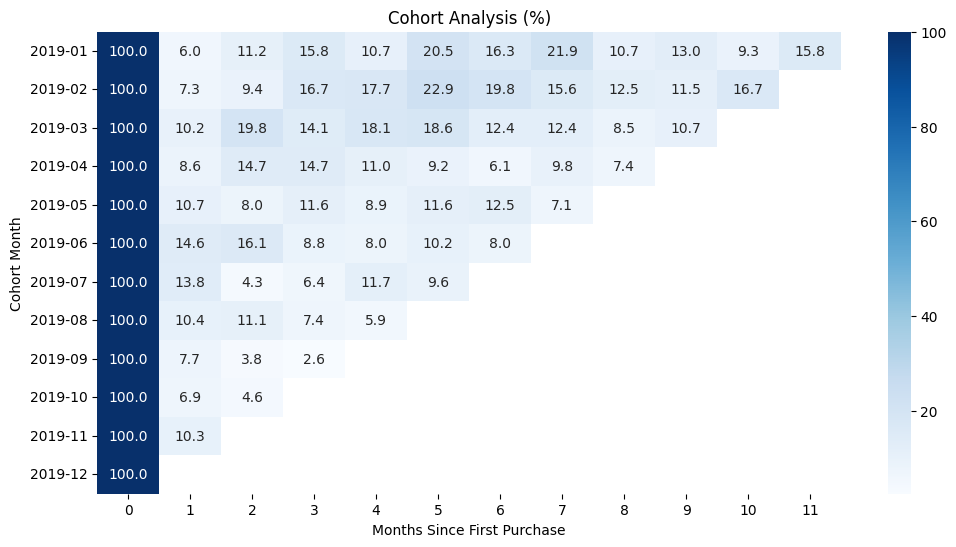

In [349]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Cohort Analysis (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()


In [350]:
#13
ltv_data = cohort_df.groupby(['CustomerID','CohortMonth'])['Invoice_Value'].sum().reset_index()
ltv_data

,CustomerID,CohortMonth,Invoice_Value
0,12346,2019-09,171.725887
1,12347,2019-03,10632.890268
2,12348,2019-06,1341.274742
3,12350,2019-12,1080.966849
4,12356,2019-09,1648.281319
...,...,...,...
1463,18259,2019-04,770.459148
1464,18260,2019-06,2434.410793
1465,18269,2019-04,140.122949
1466,18277,2019-10,274.468200


In [351]:
monthlyLtv = ltv_data.groupby('CohortMonth')['Invoice_Value'].mean().reset_index(name='avg_ltv')
monthlyLtv

,CohortMonth,avg_ltv
0,2019-01,4687.579514
1,2019-02,5241.214859
2,2019-03,3352.986791
3,2019-04,2641.998154
4,2019-05,2760.381658
5,2019-06,1816.593320
6,2019-07,2446.809062
7,2019-08,1776.274743
8,2019-09,1608.965712
9,2019-10,2683.661587


In [352]:
merged_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Discount_pct,GST,Date,Offline_Spend,Online_Spend,Discount_Decimal,GST_Decimal,Invoice_Value,FirstMonth,CustomerType
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,10.0,0.10,2019-01-01,4500,2424.5,0.1,0.0010,144.977339,2019-01,New
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,...,10.0,0.10,2019-01-01,4500,2424.5,0.1,0.0010,144.977339,2019-01,New
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,...,10.0,0.10,2019-01-01,4500,2424.5,0.1,0.0010,8.346845,2019-01,New
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,...,10.0,0.18,2019-01-01,4500,2424.5,0.1,0.0018,85.526993,2019-01,New
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,...,10.0,0.18,2019-01-01,4500,2424.5,0.1,0.0018,21.376730,2019-01,New


**Q13 Result : high ltv cohort month feb 5241 and low ltv month is sep 1608**

In [353]:
#14
from scipy.stats import ttest_ind,f_oneway
usedCoupon = merged_df[merged_df['Coupon_Status']=='Used']['Invoice_Value']
NotusedCoupon = merged_df[merged_df['Coupon_Status']=='Not Used']['Invoice_Value']
print("usedCoupon.mean =  ",usedCoupon.mean(),"  NotusedCoupon.mean = ",NotusedCoupon.mean())

usedCoupon.mean =   80.36740435809874   NotusedCoupon.mean =  82.76281123253027


In [354]:
t_stat, p_value = ttest_ind(usedCoupon, NotusedCoupon, equal_var=False)
print("t_stat = ",t_stat,"  p_value = ",p_value)

t_stat =  -1.2294076316912643   p_value =  0.21893751809503836


**Q14 Result : Although the average transaction value of coupon users differs from non-coupon users, the t-test indicates that this difference is not statistically significant (p = 0.218). Hence, we cannot conclusively state that coupon usage impacts transaction value**

In [355]:
#15

male_grp = merged_df[merged_df['Gender'] == 'M']['Invoice_Value']
female_grp = merged_df[merged_df['Gender'] == 'F']['Invoice_Value']
t_stat, p_value = ttest_ind(male_grp, female_grp)

print(t_stat, p_value)

0.27277314399975305 0.7850286692236252


In [356]:
groups = [
    grp['Invoice_Value'].values
    for _, grp in merged_df.groupby('Location')
]

f_stat, p_value = f_oneway(*groups)
print(f_stat, p_value)

2.6291359409626374 0.03258144479315369


In [357]:
merged_df['Delivery_Tier'] = pd.qcut(merged_df['Delivery_Charges'],q=3,labels=['Low', 'Medium', 'High'])
low = merged_df[merged_df['Delivery_Tier']=='Low']['Invoice_Value']
medium = merged_df[merged_df['Delivery_Tier']=='Medium']['Invoice_Value']
high = merged_df[merged_df['Delivery_Tier']=='High']['Invoice_Value']
f_stat, p_value = f_oneway(low, medium, high)
print(f_stat, p_value)

265.7302563200633 1.4806252131397538e-115


**Q15 Result :
There is no statically significant difference in Gender wise.
There is statically significant difference in Location wise and Delivery Charges.
Strongest Purchase behavior depends on Location wise and delivery charges.**

In [358]:
#16
fre_df = merged_df.groupby(['CustomerID','Tenure_Months']).agg(Purchase_Frequency=('Transaction_ID','count')).reset_index()
mid_value = fre_df['Tenure_Months'].median()
mid_value

26.0

In [359]:
fre_df['Freq_per_Month'] = fre_df['Purchase_Frequency'] / fre_df['Tenure_Months']
fre_df['Tenure_Group'] = np.where(fre_df['Tenure_Months'] <=mid_value,'Low','High')
low_tenure = fre_df[fre_df['Tenure_Group'] == 'Low']['Freq_per_Month']
high_tenure = fre_df[fre_df['Tenure_Group'] == 'High']['Freq_per_Month']
t_stat, p_value = ttest_ind(low_tenure, high_tenure, equal_var=False)
print("t_stat = ",t_stat,"  p_value = ",p_value)

t_stat =  11.496122455288127   p_value =  1.3382103097323743e-28


**Q16 Result : There is statically significant difference between Customer tenure and purchase frequency.**

In [360]:
#17
# merged_df[['Delivery_Charges', 'Quantity']].describe()
merged_df['Delivery_Tier'] = pd.qcut(merged_df['Delivery_Charges'],q=3,labels=['Low', 'Medium', 'High'])
avg_quantity = merged_df.groupby('Delivery_Tier')['Quantity'].mean()
avg_quantity

/tmp/ipython-input-401418026.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_quantity = merged_df.groupby('Delivery_Tier')['Quantity'].mean()


,Quantity
Delivery_Tier,
Low,2.971183
Medium,3.427563
High,10.253788


In [361]:
low_qty = merged_df[merged_df['Delivery_Tier'] == 'Low']['Quantity']
medium_qty = merged_df[merged_df['Delivery_Tier'] == 'Medium']['Quantity']
high_qty = merged_df[merged_df['Delivery_Tier'] == 'High']['Quantity']
f_stat, p_value = f_oneway(low_qty, medium_qty, high_qty)

print("Fstatistic ", f_stat)
print("Pvalue  ", p_value)

Fstatistic  524.2705879969701
Pvalue   3.454975645964963e-226


**Q17 Result : High delivery charges has lower ordered qty.
Lower delivery charges has Higher ordered qty.**

In [362]:
#18
low_inv = merged_df[merged_df['Delivery_Tier'] == 'Low']['Invoice_Value']
medium_inv = merged_df[merged_df['Delivery_Tier'] == 'Medium']['Invoice_Value']
high_inv = merged_df[merged_df['Delivery_Tier'] == 'High']['Invoice_Value']
f_stat, p_value = f_oneway(low_inv, medium_inv, high_inv)

print("Fstatistic ", f_stat)
print("Pvalue ", p_value)

Fstatistic  265.7302563200633
Pvalue  1.4806252131397538e-115


**Q18 Result : Since invoice value already incorporates delivery charges and taxes, the significant ANOVA result highlights that delivery pricing has a strong impact on overall customer spending, presenting an opportunity to optimize delivery fees for revenue maximization.**

In [363]:
#19
category_wise = merged_df.groupby(['Month','Product_Category'])['Invoice_Value'].sum().reset_index()
category_wise_pivot = category_wise.pivot(index='Month',columns='Product_Category',values='Invoice_Value')
category_wise_pivot

Product_Category,Accessories,Android,Apparel,Backpacks,Bags,Bottles,Drinkware,Fun,Gift Cards,Google,Headgear,Housewares,Lifestyle,More Bags,Nest,Nest-Canada,Nest-USA,Notebooks & Journals,Office,Waze
Month,,,,,,,,,,,,,,,,,,,,
2019-01,52.959413,92.882816,50063.020409,309.47819,12893.500881,1021.964285,17574.701526,409.353928,255.448660,1246.40244,2614.813018,1485.795838,9348.491562,1448.942488,NaN,9057.440999,266720.437872,7226.385433,40403.388550,947.225092
2019-02,NaN,22.507992,43672.627730,606.77994,18549.896152,493.673172,16869.547277,454.892164,320.160000,1723.34361,4306.732992,152.845190,11152.783898,476.528516,NaN,3379.324400,164381.537752,5801.446348,25650.043928,652.247842
2019-03,48.534993,207.522151,58462.488365,738.85993,13439.022519,553.609743,22297.027532,900.021594,262.631250,3131.77035,2950.675486,812.936140,9784.652066,631.200350,NaN,5578.729800,148137.940000,4510.454214,33389.722184,1165.244261
2019-04,175.414264,49.017982,93317.379787,1192.45504,12014.270749,696.440050,28046.273497,2542.633202,652.826250,1142.60452,11692.777570,170.143960,11187.592792,455.503240,NaN,5298.858900,171060.563700,22022.726539,41258.688642,885.406839
2019-05,162.854912,103.633560,62621.485296,1567.19176,9691.568706,1291.952736,16568.670920,807.179128,1060.530000,1651.27429,2995.127944,536.639040,6994.290534,435.789934,NaN,3224.878800,145714.007200,5597.501152,26890.053936,755.484818
2019-06,201.546411,174.450330,46644.492673,337.13836,10426.111886,630.502732,15037.131770,864.144276,840.420000,1258.56445,1394.953893,380.909460,6924.971139,NaN,NaN,6853.429900,144546.199100,4132.133865,21859.176684,633.757013
2019-07,1794.270124,152.423319,76911.886720,782.61992,12741.780476,1485.184557,14362.913426,1253.921680,450.225000,1791.47696,2897.646892,1356.384948,12793.587908,NaN,NaN,7239.624000,196234.751900,22843.106319,29344.776504,369.777373
2019-08,325.736128,127.868904,67260.202883,1575.86985,15506.461104,683.969548,24045.965814,404.221152,600.300000,290.74385,18483.591304,985.101760,11055.174016,NaN,17144.998400,4172.760000,164823.926800,25699.345884,28684.630632,907.264301
2019-09,1114.787868,NaN,52749.457048,758.69993,8402.287371,1598.785224,16769.232057,236.676214,420.210000,NaN,1206.008108,34.291760,8525.597711,NaN,51189.928200,2547.214300,125023.745200,6326.329568,16309.735182,676.799343


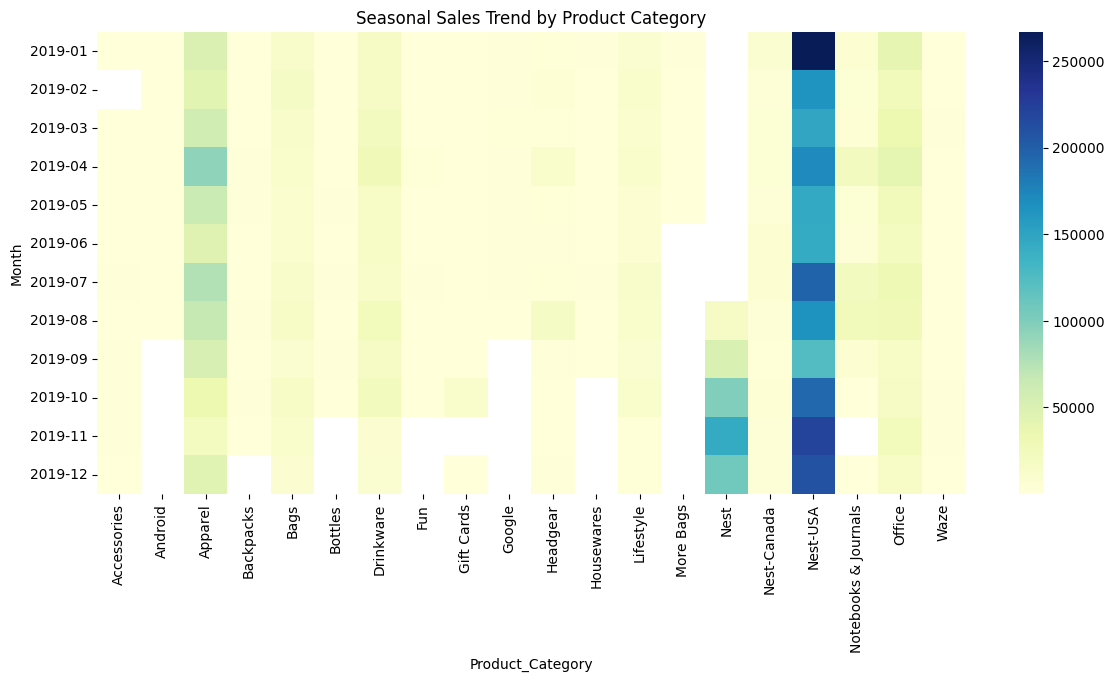

In [364]:
plt.figure(figsize=(14,6))
sns.heatmap(category_wise_pivot, cmap='YlGnBu')
plt.title('Seasonal Sales Trend by Product Category')
plt.show()

In [365]:
location_wise = merged_df.groupby(['Month','Location'])['Invoice_Value'].sum().reset_index()
location_wise_pivot = location_wise.pivot(index='Month',columns='Location',values='Invoice_Value')
location_wise_pivot

Location,California,Chicago,New Jersey,New York,Washington DC
Month,,,,,
2019-01,161217.274993,111779.768380,32246.667323,82552.817154,35376.105551
2019-02,86621.683234,109749.621276,27617.994764,42186.584708,32491.034919
2019-03,86276.710974,106259.470723,17130.334399,82680.910391,14655.616441
2019-04,123824.508559,150421.327139,44533.646814,65692.703654,19389.391356
2019-05,81996.153464,103504.077540,25756.261470,71834.823407,5578.798784
2019-06,81966.626679,82679.453920,32095.447038,56078.828772,10319.677535
2019-07,122863.160671,134644.985750,23481.395489,84308.054449,19508.761667
2019-08,113271.289628,151380.241669,21590.954982,78200.449009,18335.197042
2019-09,94458.833943,111302.912281,21541.311284,48501.568011,18085.159565


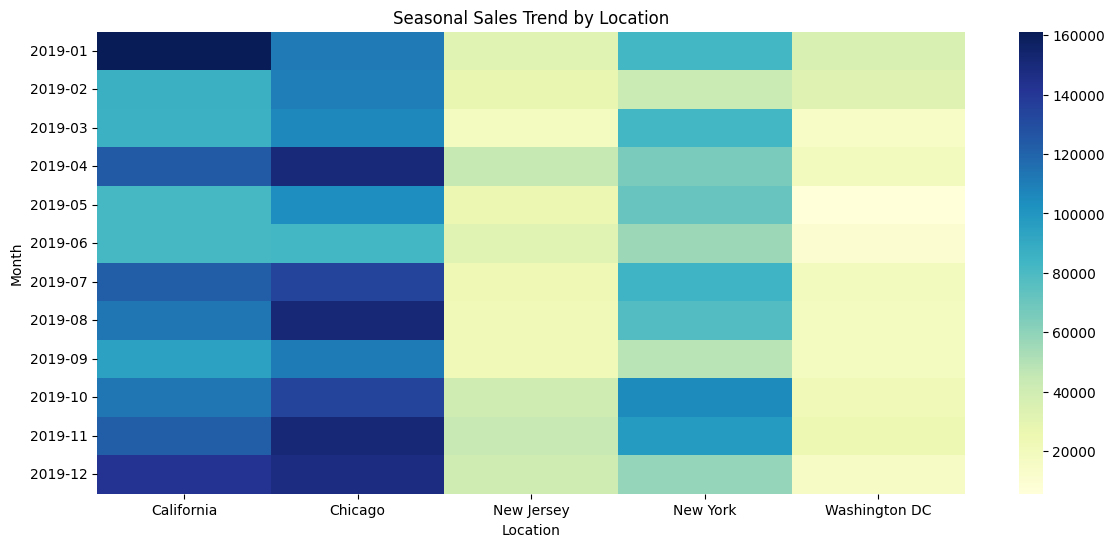

In [366]:
plt.figure(figsize=(14,6))
sns.heatmap(location_wise_pivot, cmap='YlGnBu')
plt.title('Seasonal Sales Trend by Location')
plt.show()


**Q19 Result : Can see in Heatmap Categorywise Peak and Off-Peak by month such as Nest-usa category product high sell in jan , nov,december & Off-Peak month June to dec for LongBag category.**
	`-> Can Set More Offer or Combo for High Demand Product Nest_Usa Category from Jan to Dec and For Remaining Category Product , we can launch Coupon , More Discount .`

**Similary shows for by location Peak Month June , December for California & Off-Peak Month June-July for WashingtonDC .**
	`->Maintain or Maximize Inventory of California Location at month January , April and June-December.`


In [367]:
#20
daily_sale = merged_df.groupby('Transaction_Date')['Invoice_Value'].sum().reset_index()
daily_sale['Day'] = daily_sale['Transaction_Date'].dt.day_name()
daily_sale

,Transaction_Date,Invoice_Value,Day
0,2019-01-01,7735.992525,Tuesday
1,2019-01-02,12992.961862,Wednesday
2,2019-01-03,25127.244096,Thursday
3,2019-01-04,16481.366322,Friday
4,2019-01-05,18070.672352,Saturday
...,...,...,...
360,2019-12-27,10343.295411,Friday
361,2019-12-28,8383.033462,Saturday
362,2019-12-29,9018.836088,Sunday
363,2019-12-30,6063.940060,Monday


In [368]:
dailyWiseSale = daily_sale.groupby('Day')['Invoice_Value'].mean().reset_index()
dailyWiseSale

,Day,Invoice_Value
0,Friday,15283.999236
1,Monday,6285.757969
2,Saturday,12155.950001
3,Sunday,12405.878112
4,Thursday,15006.305073
5,Tuesday,6800.620019
6,Wednesday,14730.743977


In [369]:
avg_sale = dailyWiseSale['Invoice_Value'].mean()
high_sale = dailyWiseSale[dailyWiseSale['Invoice_Value']>avg_sale]['Invoice_Value']
low_sale = dailyWiseSale[dailyWiseSale['Invoice_Value']<avg_sale]['Invoice_Value']
print(f"avg_sale {avg_sale}")
print(f"high_sale {high_sale}")
print(f"low_sale {low_sale}")

avg_sale 11809.89348380141
high_sale 0    15283.999236
2    12155.950001
3    12405.878112
4    15006.305073
6    14730.743977
Name: Invoice_Value, dtype: float64
low_sale 1    6285.757969
5    6800.620019
Name: Invoice_Value, dtype: float64


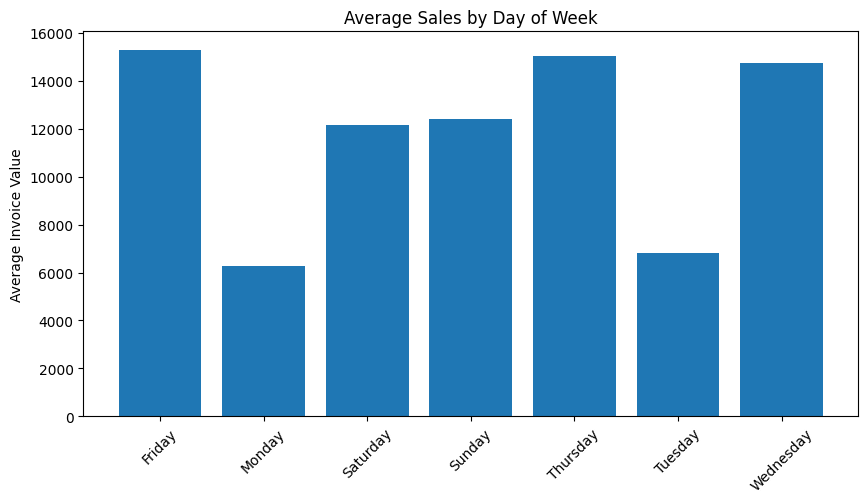

In [370]:
plt.figure(figsize=(10,5))
plt.bar(dailyWiseSale['Day'], dailyWiseSale['Invoice_Value'])
plt.xticks(rotation=45)
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Invoice Value')
plt.show()


**Q20 Result :
Highest Sales Days is Friday and above average sale days are Saturday,Sunday,Thursday,Wednesday.
Lowest Sales Days is Monday and Below Avereage sale day are Monday & Tuesday.**